Question 2 - using a neural network method to predict the species of a penguin based on certain features, such as culmen length, depth, flipper length and body mass using a multilayer perceptron (MLP). This is a neural network consisting of layers that can predict imformation based on an input by feeding this input through hidden layers to conclude an output.  I have chosen MLP because the penguin size data is tabular and continuous, which is the type of data a MLP is able to handle. Other neural network options take other types of data, such as image data, or data that relates to points in spacetime. Scikit-learn provides a way to use MLP without needing to code the entire neural network from scratch.

To start creating and training a neural network on this data, we need to import some helpder functions like we did in the first notebook. Firstly, we will import some packages that allow the import of helper functions from the functions file. Chatgpt was used to help with this.

In [3]:
#imports to help with function imports
#sys and os are operating system packages that allow me to access the other files
import sys 
import os
sys.path.append(os.path.abspath(".."))

Now, we'll continue with the imports. For this neural network, we'll need pandas to see the data in a dataframe, numpy to use mathematical features, seaborn and matplotlib for data visualisation, and scikit-learn to create and train the neural network. A few different scikit-learn packages are required for this to work properly, which will also be imported.

In [4]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

Finally, we need to import the helper functions from the functions file. The first imports (sys, os) allow us to access them from their separate file. The helper files load in the data, split it, standardize it, train the neural network and evaluate it. The purpose of each funtion is commented next to the import. 

In [5]:
from functions import load_data #loads the cleaned penguin size dataset from where it is stored
from functions import split_data #splits the data into training and testing sets
from functions import split_train_test #splits features and labels into training and testing sets
from functions import scale_features #scales the training features using standard scaler
from functions import train_neural_network #trains mlp neural network on training data
from functions import evaluate_neural_network #evaluates the performance of the trained neural network

To start training the neural network, we need to start by importing the dataset for penguin sizes. The dataset has 7 columns for species, island, culmen length, depth, flipper length, body mass, and sex. I cleaned the data by removing all the null values for important pieces of data. The island of residence and sex is not important in determining the species of the penguin, so null values were left in for those rows. The cleaned data has complete sets of species, culmen length, depth, flipper length and body mass which will be used to train the neural network. By using the load_data funtion, we can import the data into this notebook.

In [6]:
#using the load_data function to load the cleaned penguin size dataset
df =load_data("../../data/processed/penguins_size_cleaned.csv") #importing the dataset using the path to the data
df.head() #showing the first 5 rows of the dataset

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


Now that the data has been imported into the notebook, we need to split the columns into target data and feature data. The target data is what we are trying to predict, species, and the feature data is what we are using to predict the target, so culmen length, depth, flipper length and body mass. We will use the split_data function to break up the columns in this way.

In [7]:
#splitting the data into feature data and target data
feature_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g',] #feature variables to use
target_col = 'species' #target variabke to predict - species
x, y = split_data(df, feature_cols, "species") #feature and target variables have been assigned to x and y

Next is a step that neural networks need because they cannot be trained on strings of characters. We need to encode the target variables into numbers so the neural network can process them. For this, we use a built-in feature from scikit-learn, and keep a log of which species gets which number for later in the notebook.

In [8]:
#using the label encoder to give target values numerical values
labels = LabelEncoder() #calling the label encoder from sklearn
y = labels.fit_transform(y) #encoding the species labels into numerical values
print("Encoded species labels:", labels.classes_) #printing the encoded species labels for later
#adelie = 0, chinstrap = 1, gentoo = 2

Encoded species labels: ['Adelie' 'Chinstrap' 'Gentoo']


Now that the data has been encoded, its time to split it into a training set and a test set using the split_train_test function. In notebook 1, we used an 80-20 split and will do so here too. This provides the neural network a set of 80% of the data to be trained on and keeps 20% for testing later on. The input data is assinged a weight which is then used in conjunction with other features, such as the relu activation function to clean how the data is correlated. The data is passed though layers of the network and predictions are made, checked, and calculations are performed to find how mathematically correct these predictions are. The mlp then goes back and adjusts based on the performance results and repeats this process until it reaches the maximum number of iterations, or epochs. Then, the 20% of unseen data reserved for testing is used to test the accuracy of the neural networks predictions. 

In [9]:
#splitting the dataset into 80% training and 20% testing 
#output is x and y sets for both training and testing
#test size is 20% of dataset, random state set at 42 generates the same split each time for reproducibility
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size=0.2, random_state=42)

Now that the dataset has been allocated into training and testing, we need to scale the data for the neural network. This is done with another built in feature of scikit-learn and involves finding the mean of the feature and removing it then divide it by the standard deviation. This results in the values being comparable against each other and means features can be compared directly against each other no matter which feature, because the difference is removed and they become comparable. We can do this using our scale_features helper function.

In [10]:
#using the scale_features function to standardize the data
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #return a scaled version of the training and 
#testing features

Finally, the data has been prepared for use in training the neural network. To create and train it, we use the train_neural_network helper function that works on the built in scikit-learn feature to create and train a mlp neural network. The function takes the scaled training data, a number of layers (2 layers of 16 neurons in this case), a number of epochs to iterate through which we have set to 1000 for a high level of precision and a set random state for reproducibility. This will return a neural network trained on the scaled test feature data and the test target data. The activation and solver variables have been set to standard ones for a mlp model and they handle complex patterns and optimisation respectively.

In [11]:
#creating and training the neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16, 16), epochs=1000)
#neural network has 2 hidden layers of 16 neurons and are trained 1000 times.

The neural network has now been trained 1000 times on the training data. Next, we want to use the testing data to check the accuracy of the model. The test data is unseen to the model, so it must predict the target based on the relationships it has identified from the test data. We can use our evaluate_neural_network function which returns the accuracy and classification report of the neural network. 

In [12]:
#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

Accuracy of the neural network:
 0.9855072463768116
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        35
           1       0.92      1.00      0.96        12
           2       1.00      1.00      1.00        22

    accuracy                           0.99        69
   macro avg       0.97      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



The data printed above shows us how accurate the mlp is. We can see it has a high accuracy of 0.985507 and that overall it performed really well. The analysis also tells us how well the model performed for each class. For adelie penguins (0), the model correctly predicted 100% of them but only recalled 97% correctly, which averages to a score of 0.99/1 for class 0 out of 35 pieces of test data. For class 1, chinstrap, the model was less accurate - only 92% of the penguins were correctly identified, however 100% were correctly recalled. However, the sample for this was smaller, only 12 penguins. Finally, for class 2 (gentoo) penguins, the model precited correctly 100% of the time and recalled 100% correctly, giving a perfect score of 1 out of 22 penguins tested. Overall, the model precision is good as shown by the final 3 rows, which average the models performance and weight them. Class 1 penguins appears to be far less accurate but it only misidentified one penguin, so this would be due to its smaller sample size.

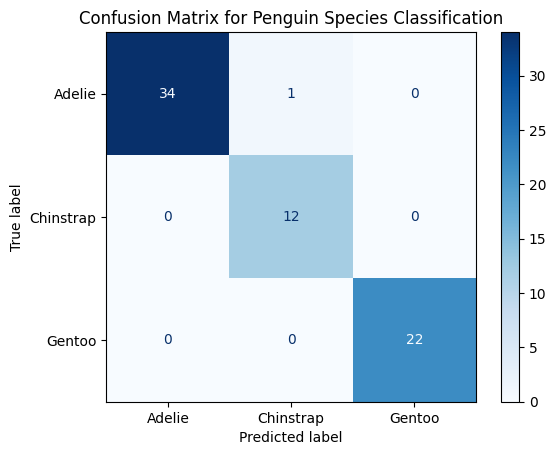

In [13]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/02_confusion_matrix.png")
plt.show()

The confusion matrix shows us the areas of the dataset that the neural network got confused with. It visualises the data from the analysis section, so here we can see a graphical representation of the one incorrect prediction for the chinstrap penguins.

Neural networks do not have feature importance in the same way we looked at one in the random forest, but it has a way to test this. By using a built in feature in scikit-learn called permutation importance, we can check the accuracy differences in processing the data to train the neural network. We can use this function now to look at the features that contributed most to the predictions: 

In [15]:
#using permutation importance to see which features are most important to the model
result = permutation_importance(mlp, x_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': result.importances_mean}) 
#creating a dataframe to hold feature names and their importance scores
importance_df = importance_df.sort_values(by='Importance', ascending=False) #sorting features by importance
display(importance_df) #displaying the feature importance dataframe

,Feature,Importance
0,culmen_length_mm,0.313043
1,culmen_depth_mm,0.114493
3,body_mass_g,0.063768
2,flipper_length_mm,0.040580


/var/folders/qt/0r6nhhp92hx_rhfxm0rwpk100000gn/T/ipykernel_26226/2171783281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis") #creating a horizontal bar plot and selecting colour


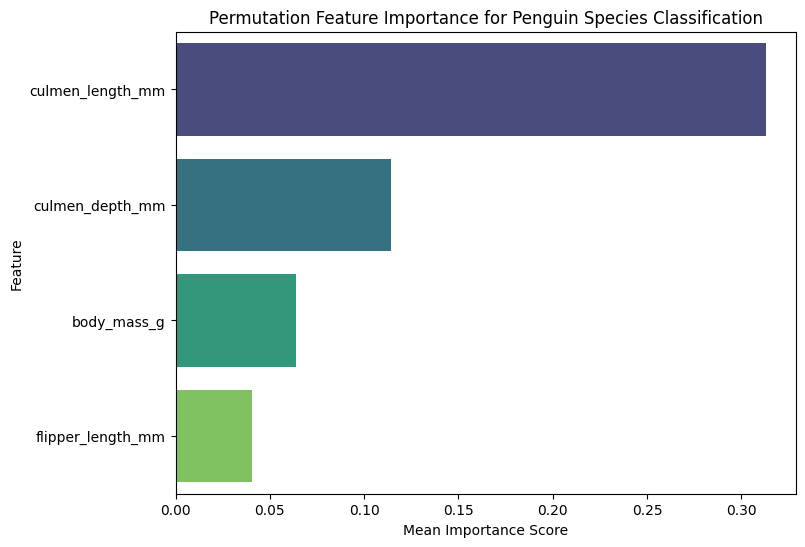

In [17]:
#plotting permutation importance into a graph for visualisation
features = importance_df['Feature'] #setting feature names
importances = importance_df['Importance'] #setting importance scores from permutation importance
plt.figure(figsize=(8, 6)) #setting figure size
sns.barplot(x=importances, y=features, palette="viridis") #creating a horizontal bar plot and selecting colour
plt.title("Permutation Feature Importance for Penguin Species Classification") #adding title
plt.xlabel("Mean Importance Score") #adding x label
plt.ylabel("Feature") #adding y label
plt.savefig("../../images/02_permutation_importance.png") #saving plot to images folder
plt.show() #showing graph

The permutation importance shows us that the culmen length followed by depth were the most important for determining penguin species, followed by body mass and flipper length. This was measured by calculating the decrease in prediction accuracy after randomly permutating the features. 

MLP worked well for my dataset as shown by the 99% prediction accuracy. I chose it because the data is tabular and continuous with no temporal or spatial components as opposed to other types of neural networks that handle image data, or discrete data. I chose not to involve deep learning as the dataset is fairly small with around 340 values so would be excessive for this dataset. It handled the non linear relationships between the features well and performed very well, with only one incorrect prediction (that seemed larger than it was due to the small test data size). 

Compared to the random forest classification used in method one, the multilayer perceptron improved perfomance. The random forest gave results that were easier to interpret, but work better with linearity compared to the non-linear capabilities of the mlp. The random forest also required less data processing, as standardization was not needed and was easier to see where the predictions came from. On the other hand, the mlp neural network had a higher accuracy and prediction power, but it wasnt as clear how it came to these results due to its ability to handle and connect non-linear data. It did require the data to be scaled and will not function correctly without this, and requires care to not overfit the data. To conclude, both methods were accurate and worked well, although the neural network approach worked slightly better.